In [4]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [8]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [9]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

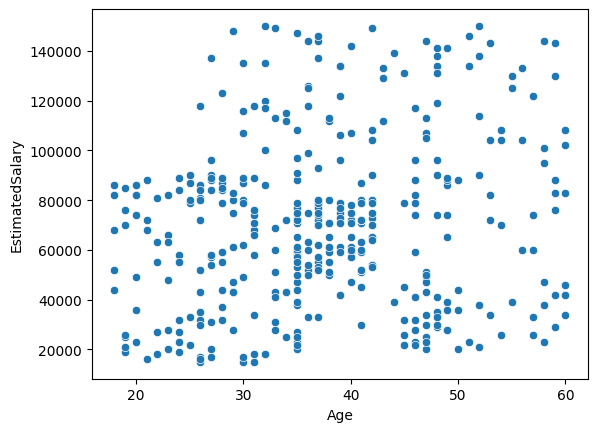

In [12]:
sns.scatterplot(x = df.iloc[:,0],y = df.iloc[:,1])b

In [13]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [19]:
X.value_counts()

Age  EstimatedSalary
41   72000              4
40   57000              3
45   22000              2
29   43000              2
39   71000              2
                       ..
33   31000              1
     28000              1
32   150000             1
     135000             1
33   149000             1
Name: count, Length: 365, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [21]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [34]:
model = Sequential()

model.add(Dense(32,activation='relu',input_dim=2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [35]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [37]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6336 - loss: 745.7859 - val_accuracy: 0.4000 - val_loss: 250.9532
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4490 - loss: 178.6989 - val_accuracy: 0.6000 - val_loss: 56.0028
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4277 - loss: 65.2411 - val_accuracy: 0.6000 - val_loss: 27.2933
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5209 - loss: 35.7254 - val_accuracy: 0.4000 - val_loss: 4.5872
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4250 - loss: 16.6469 - val_accuracy: 0.4000 - val_loss: 16.0484
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4910 - loss: 10.8011 - val_accuracy: 0.4000 - val_loss: 23.2014
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4927 - loss: 18.6356 - val_accuracy: 0.4000 - val_loss: 17.8917
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4907 - loss: 13.0411 - val_ac

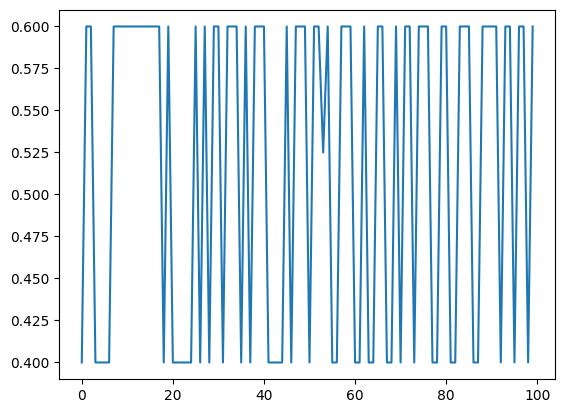

In [38]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

In [ ]:
# Applying scaling

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: >

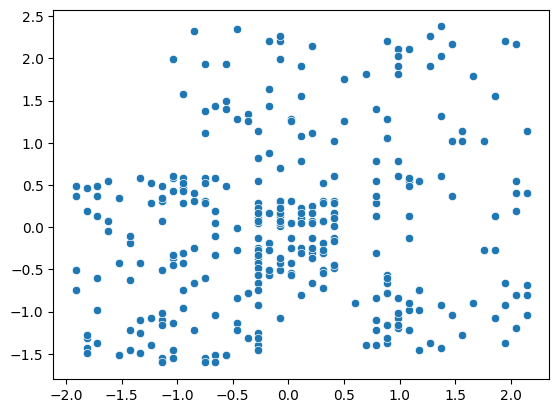

In [40]:
sns.scatterplot(x = X_train_scaled[:,0],y = X_train_scaled[:,1])

In [42]:
model = Sequential()

model.add(Dense(32,activation='relu',input_dim=2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6594 - loss: 0.7137 - val_accuracy: 0.6000 - val_loss: 0.6912
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6685 - loss: 0.6744 - val_accuracy: 0.6500 - val_loss: 0.6414
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7504 - loss: 0.6282 - val_accuracy: 0.7875 - val_loss: 0.5961
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8452 - loss: 0.5869 - val_accuracy: 0.8125 - val_loss: 0.5568
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8406 - loss: 0.5589 - val_accuracy: 0.8125 - val_loss: 0.5226
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8510 - loss: 0.5280 - val_accuracy: 0.8000 - val_loss: 0.4899
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8650 - loss: 0.5037 - val_accuracy: 0.8125 - val_loss: 0.4598
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8923 - loss: 0.4496 - val_accuracy: 0.8125 - val_l

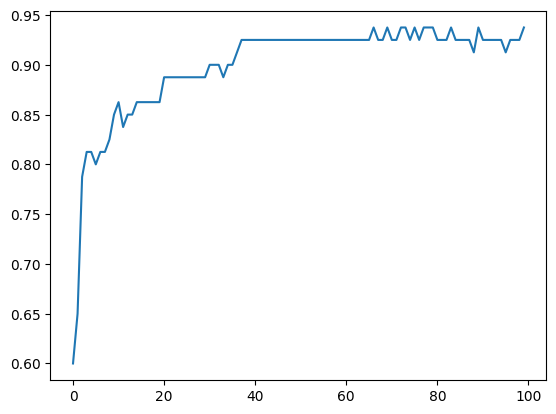

In [43]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])